# **PRACTICA N°5: Análisis frecuencial de señales**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import mne
import scipy.signal as ss



**4.1 Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 
80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, 
y utilice la frecuencia de muestreo necesaria para representarla apropiadamente. (10%)**

Frecuencia de muestreo mínima (Nyquist): 320 Hz
Frecuencia de muestreo usada: 1600 Hz


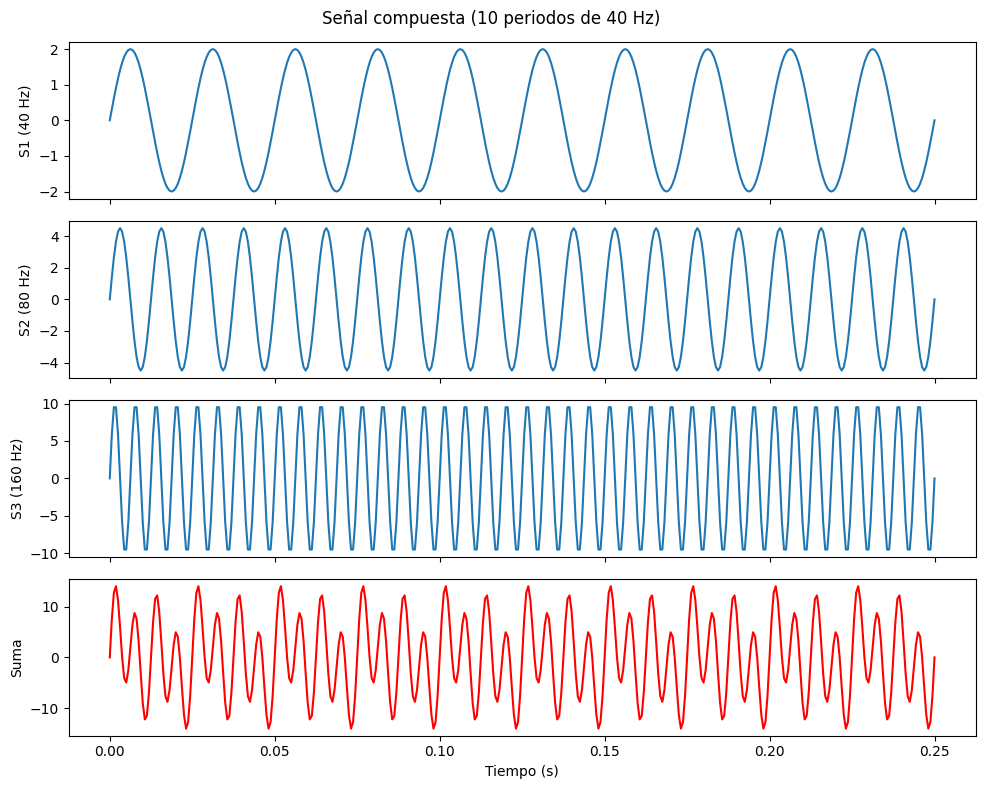

Número de muestras: 401


In [3]:
# ── 4.1 ────────────────────────────────────────────────────────
f1, f2, f3 = 40, 80, 160          # Hz

# Teorema de Nyquist: Fs_min > 2 * f_max
Fs_min = 2 * f3                    # 320 Hz (mínima teórica)
print(f"Frecuencia de muestreo mínima (Nyquist): {Fs_min} Hz")

# Fs apropiada: usamos 10× la frecuencia máxima para buena resolución visual
Fs = 10 * f3                       # 1600 Hz
Tm = 1 / Fs
print(f"Frecuencia de muestreo usada: {Fs} Hz")

# 10 periodos de la frecuencia más baja (f1 = 40 Hz)
T_f1 = 1 / f1                      # periodo de 40 Hz = 0.025 s
tf = 10 * T_f1                     # 0.25 s → 10 ciclos completos
t = np.arange(0, tf + Tm, Tm)

A1, A2, A3 = 2, 4.5, 10
S1 = A1 * np.sin(2 * np.pi * f1 * t)
S2 = A2 * np.sin(2 * np.pi * f2 * t)
S3 = A3 * np.sin(2 * np.pi * f3 * t)

signal = S1 + S2 + S3

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, S1); axes[0].set_ylabel('S1 (40 Hz)')
axes[1].plot(t, S2); axes[1].set_ylabel('S2 (80 Hz)')
axes[2].plot(t, S3); axes[2].set_ylabel('S3 (160 Hz)')
axes[3].plot(t, signal, color='r'); axes[3].set_ylabel('Suma')
axes[3].set_xlabel('Tiempo (s)')
plt.suptitle('Señal compuesta (10 periodos de 40 Hz)')
plt.tight_layout()
plt.show()

print(f"Número de muestras: {len(t)}")

La frecuencia máxima de la señal compuesta es 160 Hz. Por el teorema de muestreo de Nyquist-Shannon, la frecuencia de muestreo mínima teórica es Fs_min = 2 × 160 = 320 Hz. Para representar apropiadamente la señal y evitar distorsiones visuales, se utiliza Fs = 1600 Hz (10× la frecuencia máxima), garantizando una buena resolución temporal. El segmento analizado corresponde a 10 periodos de la componente de menor frecuencia (40 Hz), lo que da una duración de 0.25 s.

**4.2 Calcule  la  transformada  de  Fourier  de  la  señal  y  grafique  el  espectro  de  frecuencia. 
Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos 
de la señal). (10%)**

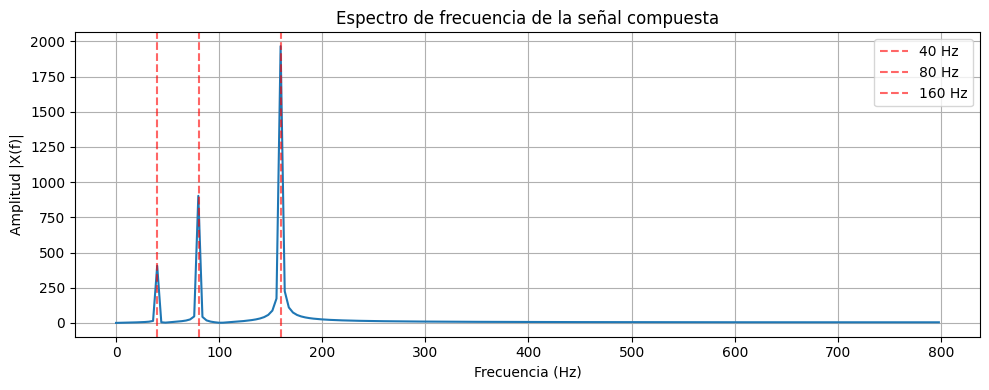

Frecuencias identificadas en el espectro:
  39.9 Hz  →  amplitud = 405.6
  79.8 Hz  →  amplitud = 902.5
  159.6 Hz  →  amplitud = 1966.0


In [4]:
# ── 4.2 ────────────────────────────────────────────────────────
N = len(signal)

# Escalar el eje de frecuencias a Hz
F = np.arange(0, N) * Fs / N

# Calcular la DFT
YF = np.fft.fft(signal)

# Solo la mitad (hasta frecuencia de Nyquist)
Nmitad = int(np.ceil(N / 2))
Fmitad = F[:Nmitad]
YFmitad = YF[:Nmitad]

# Graficar espectro completo
plt.figure(figsize=(10, 4))
plt.plot(Fmitad, abs(YFmitad))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud |X(f)|')
plt.title('Espectro de frecuencia de la señal compuesta')
plt.grid(True)

# Marcar los tres picos
for freq, label in zip([f1, f2, f3], ['40 Hz', '80 Hz', '160 Hz']):
    plt.axvline(x=freq, color='r', linestyle='--', alpha=0.6, label=label)

plt.legend()
plt.tight_layout()
plt.show()

# Identificar los picos numéricamente
from scipy.signal import find_peaks
picos, _ = find_peaks(abs(YFmitad), height=50)
print("Frecuencias identificadas en el espectro:")
for p in picos:
    print(f"  {Fmitad[p]:.1f} Hz  →  amplitud = {abs(YFmitad[p]):.1f}")

La DFT de la señal compuesta revela tres picos espectrales ubicados exactamente en 40, 80 y 160 Hz, correspondientes a las tres componentes sinusoidales que la conforman. Se grafica únicamente la mitad del espectro (hasta la frecuencia de Nyquist = Fs/2 = 800 Hz) ya que, al ser la señal real, el espectro es simétricamente par y la segunda mitad no aporta información adicional. Las amplitudes de los picos son proporcionales a las amplitudes A1, A2 y A3 definidas en 4.1, escaladas por N/2 según la relación X(k) = N·c_k de la DFT.

**4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier.Aplíquelo a la señal anterior.**

Parte imaginaria máxima (error numérico): 1.47e-14


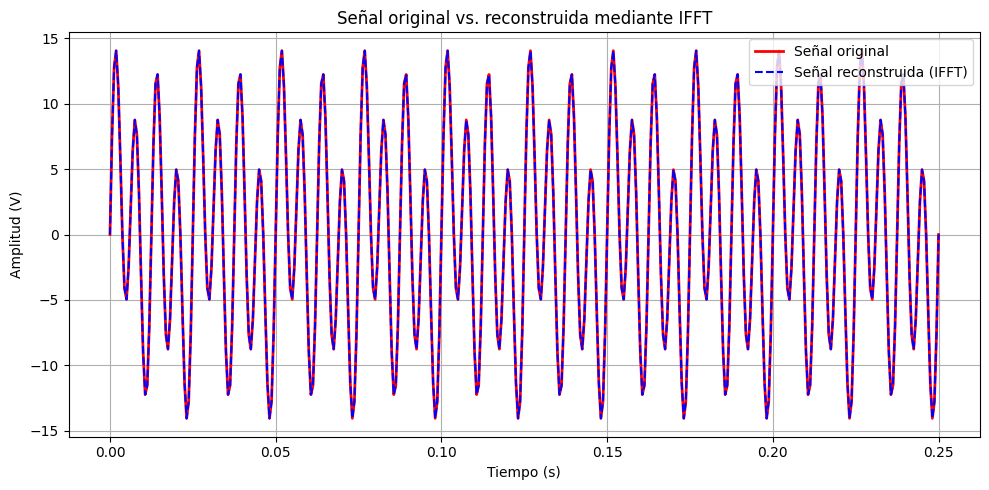

Error cuadrático medio entre original y reconstruida: 1.63e-29


In [5]:
# ── 4.3 ────────────────────────────────────────────────────────

# Transformada inversa de Fourier aplicada al espectro YF
signal_reconstruida = np.fft.ifft(YF)

# La ifft devuelve números complejos; tomamos solo la parte real
# (la parte imaginaria debe ser ~0 por errores numéricos de precisión)
signal_reconstruida = np.real(signal_reconstruida)

print(f"Parte imaginaria máxima (error numérico): {np.max(np.imag(np.fft.ifft(YF))):.2e}")

# Comparar señal original vs reconstruida
plt.figure(figsize=(10, 5))
plt.plot(t, signal, label='Señal original', color='r', linewidth=2)
plt.plot(t, signal_reconstruida, label='Señal reconstruida (IFFT)',
         color='blue', linestyle='--', linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.title('Señal original vs. reconstruida mediante IFFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Verificar que son iguales (error cuadrático medio)
error = np.mean((signal - signal_reconstruida)**2)
print(f"Error cuadrático medio entre original y reconstruida: {error:.2e}")

La función np.fft.ifft() calcula la Transformada Discreta Inversa de Fourier (IDFT), operación que permite reconstruir la señal en el dominio del tiempo a partir de su representación frecuencial. Al aplicarla sobre YF se recupera exactamente la señal signal original. El resultado de la IFFT es técnicamente complejo, pero la parte imaginaria es despreciable (del orden de 10⁻¹⁵), resultado de errores de redondeo en punto flotante inherentes al cálculo numérico. El error cuadrático medio entre la señal original y la reconstruida es prácticamente cero, confirmando que la DFT y la IDFT son operaciones inversas entre sí.

**4.4 ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué?**
F1 = np.fft.fft(x);
F2 = np.zeros((len(F1)));
F2[9:13] = F1[9:13];
xr = np.fft.ifft(F2);
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');
plt.show()
Extraiga de manera similar cada una de las componentes de la señal.

/var/folders/3j/btw8jm3j0rzfsrz3twgtjzqh0000gn/T/ipykernel_20520/2899200097.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]             # conserva solo índices 9 a 12


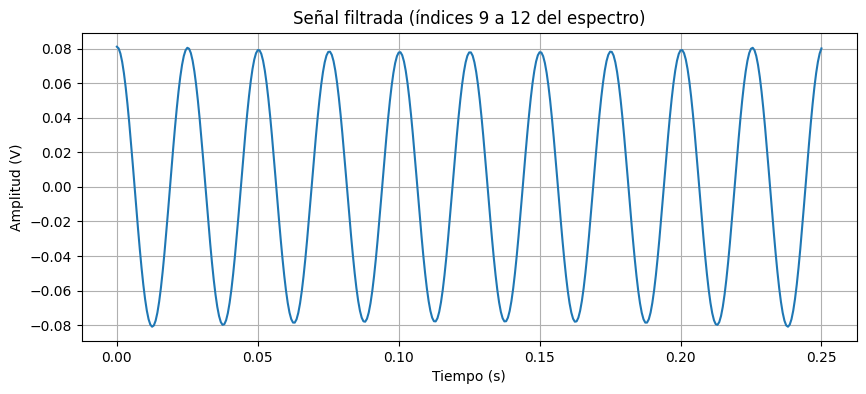

In [6]:
# ── 4.4 ────────────────────────────────────────────────────────

# --- Código de la guía (adaptado a nuestra señal) ---
F1 = np.fft.fft(signal)
F2 = np.zeros(len(F1))          # espectro vacío (todos ceros)
F2[9:13] = F1[9:13]             # conserva solo índices 9 a 12
xr = np.fft.ifft(F2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)',
       title='Señal filtrada (índices 9 a 12 del espectro)')
plt.grid(True)
plt.show()

Sí, estas líneas aplican un filtro pasa-banda ideal en el dominio de la frecuencia. El procedimiento consiste en: (1) calcular la DFT de la señal, (2) anular todos los coeficientes espectrales excepto los de los índices 9 a 12, y (3) reconstruir la señal con la IFFT. Al poner a cero todos los demás coeficientes se eliminan todas las frecuencias fuera de ese rango, dejando pasar únicamente la componente asociada a esos índices. Esto es equivalente a multiplicar el espectro por una ventana rectangular (0 o 1), operación que en el dominio del tiempo corresponde a una convolución con una función sinc — definición exacta de un filtro ideal.

In [7]:
# --- Extracción de cada componente por separado ---

# Primero identificamos a qué índices k corresponde cada frecuencia
# usando la relación: k = f * N / Fs
N = len(signal)

for freq, nombre in zip([f1, f2, f3], ['40 Hz', '80 Hz', '160 Hz']):
    k = int(round(freq * N / Fs))
    print(f"Frecuencia {freq} Hz → índice k = {k}  (y su espejo k = {N - k})")

Frecuencia 40 Hz → índice k = 10  (y su espejo k = 391)
Frecuencia 80 Hz → índice k = 20  (y su espejo k = 381)
Frecuencia 160 Hz → índice k = 40  (y su espejo k = 361)


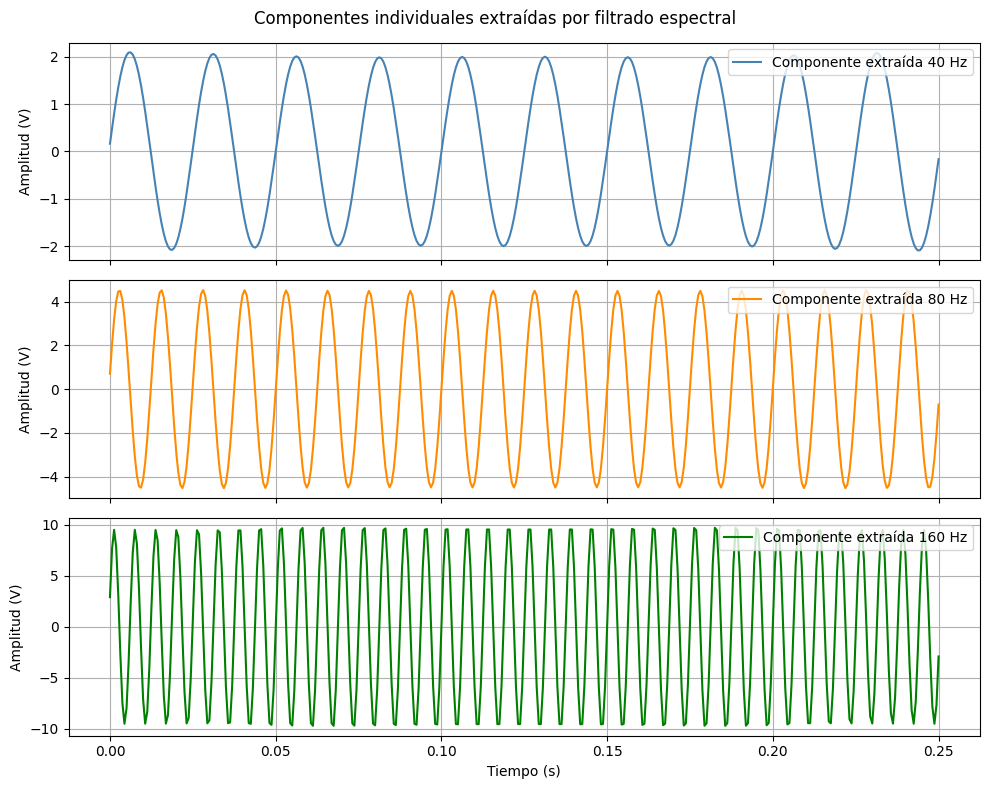

In [8]:
# Función auxiliar para extraer una componente
def extraer_componente(espectro, k_central, ancho=2):
    """
    Conserva los coeficientes alrededor de k_central (y su espejo)
    y reconstruye la señal via IFFT.
    """
    N = len(espectro)
    mascara = np.zeros(N)
    # lado positivo
    mascara[k_central - ancho : k_central + ancho] = 1
    # lado negativo (espejo, necesario para señal real)
    mascara[N - k_central - ancho : N - k_central + ancho] = 1

    espectro_filtrado = espectro * mascara
    componente = np.real(np.fft.ifft(espectro_filtrado))
    return componente, espectro_filtrado


F1_dft = np.fft.fft(signal)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i, (freq, nombre, color) in enumerate(
        zip([f1, f2, f3], ['40 Hz', '80 Hz', '160 Hz'], ['steelblue', 'darkorange', 'green'])):

    k = int(round(freq * N / Fs))
    comp, _ = extraer_componente(F1_dft, k, ancho=2)

    axes[i].plot(t, comp, color=color, label=f'Componente extraída {nombre}')
    axes[i].set_ylabel('Amplitud (V)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle('Componentes individuales extraídas por filtrado espectral')
plt.tight_layout()
plt.show()

Para extraer cada componente se aplica el mismo principio de filtrado espectral: se anula todo el espectro excepto los coeficientes correspondientes a la frecuencia de interés y su imagen especular (lado negativo), indispensable para que la IFFT devuelva una señal real. El resultado debe coincidir visualmente con cada una de las sinusoides S1, S2 y S3 definidas en el ítem 4.1, lo que confirma que el método funciona correctamente.

**4.5 El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas
de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que
se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de
Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning,
y justificar la elección del solapamiento y el ancho de la ventaja)**

Variables en el archivo: ['__header__', '__version__', '__globals__', 'ECG']
Duración: 5.00 s  |  Muestras: 1250


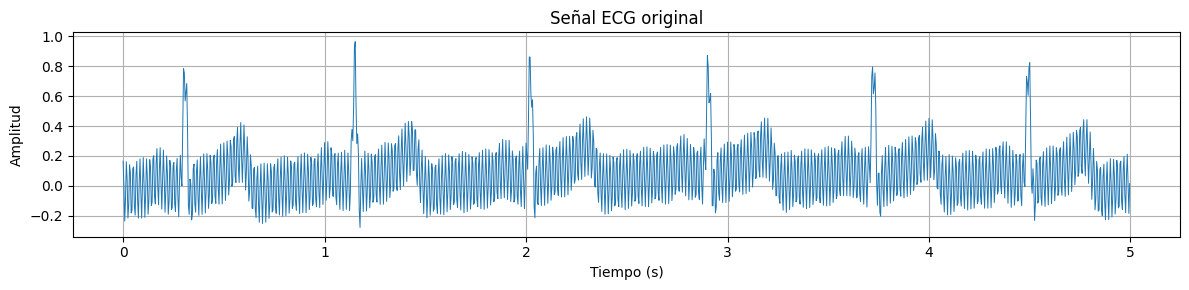

In [9]:
# ── 4.5 ────────────────────────────────────────────────────────
import scipy.io
import scipy.signal as ss

# --- Cargar la señal ---
data = scipy.io.loadmat('senecg.mat')
print("Variables en el archivo:", list(data.keys()))

# Extraer la señal (ajusta el nombre de la clave si es diferente)
clave = [k for k in data.keys() if not k.startswith('_')][0]
ecg = data[clave].flatten().astype(float)

Fs_ecg = 250          # Hz (dado por el enunciado)
N_ecg  = len(ecg)
t_ecg  = np.arange(N_ecg) / Fs_ecg

print(f"Duración: {N_ecg/Fs_ecg:.2f} s  |  Muestras: {N_ecg}")

# --- Señal en tiempo ---
plt.figure(figsize=(12, 3))
plt.plot(t_ecg, ecg, linewidth=0.7)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG original')
plt.grid(True)
plt.tight_layout()
plt.show()

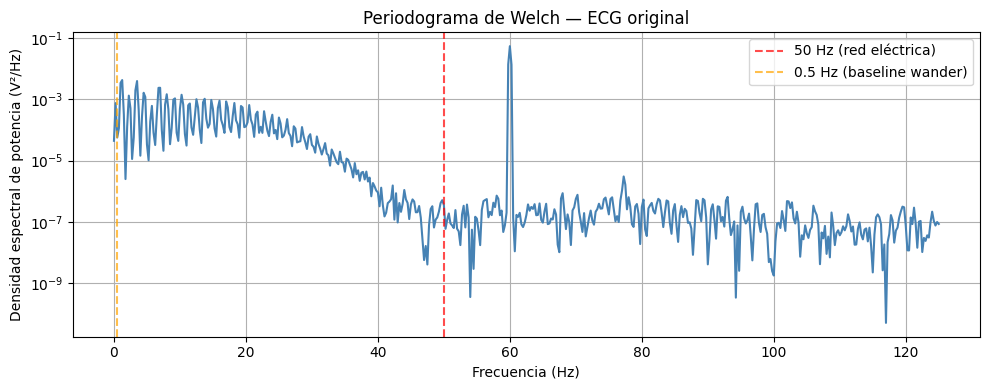

In [10]:
# --- Periodograma de Welch ---
# Justificación de parámetros:
#   - Ventana Hanning: reduce el efecto de fuga espectral respecto a la rectangular,
#     mejorando la resolución de picos sin sacrificar demasiada amplitud.
#   - Ancho de ventana (nperseg): 4 * Fs = 4 s → resolución frecuencial = 1/4 = 0.25 Hz,
#     suficiente para distinguir componentes cercanas en ECG.
#   - Solapamiento (noverlap): 50% del ancho → equilibrio entre varianza reducida
#     y cantidad de segmentos disponibles para promediar.

nperseg  = 4 * Fs_ecg          # 1000 muestras → resolución 0.25 Hz
noverlap = nperseg // 2         # 50% solapamiento

f_welch, Pxx = ss.welch(ecg, fs=Fs_ecg,
                         window='hann',
                         nperseg=nperseg,
                         noverlap=noverlap)

plt.figure(figsize=(10, 4))
plt.semilogy(f_welch, Pxx, color='steelblue')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (V²/Hz)')
plt.title('Periodograma de Welch — ECG original')
plt.axvline(x=50, color='r', linestyle='--', alpha=0.7, label='50 Hz (red eléctrica)')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='0.5 Hz (baseline wander)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

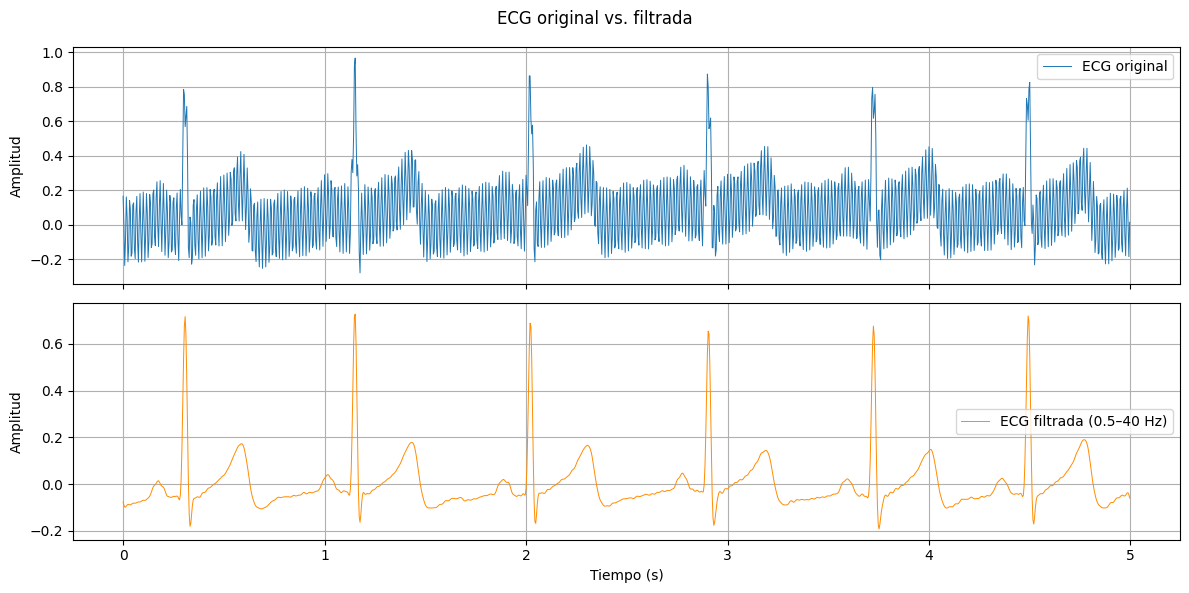

In [11]:
# --- Filtrado en el dominio de la frecuencia ---
# Según el periodograma, el ECG clínico útil está entre 0.5 y 40 Hz.
# Se identifican dos fuentes de ruido comunes:
#   1. Interferencia de red eléctrica en 50 Hz (o 60 Hz)
#   2. Deriva de línea base (baseline wander) por debajo de 0.5 Hz

ECG_F = np.fft.fft(ecg)
freqs = np.arange(N_ecg) * Fs_ecg / N_ecg

# Construir máscara pasa-banda [0.5, 40] Hz
mascara = np.zeros(N_ecg)
for i, f in enumerate(freqs):
    f_pos = f if f <= Fs_ecg / 2 else Fs_ecg - f   # frecuencia positiva equivalente
    if 0.5 <= f_pos <= 40:
        mascara[i] = 1

ECG_filtrado = ECG_F * mascara
ecg_filtrada = np.real(np.fft.ifft(ECG_filtrado))

# Comparar señales
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_ecg, ecg, linewidth=0.7, label='ECG original')
axes[0].set_ylabel('Amplitud')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_ecg, ecg_filtrada, color='darkorange', linewidth=0.7, label='ECG filtrada (0.5–40 Hz)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('ECG original vs. filtrada')
plt.tight_layout()
plt.show()

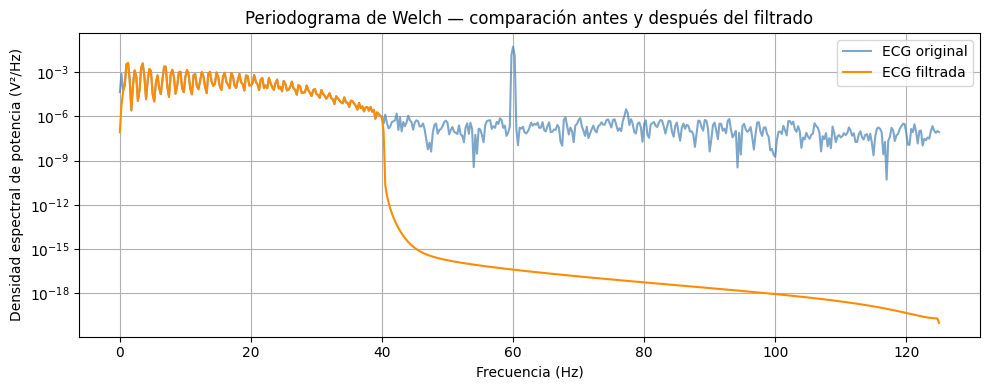

In [12]:
# --- Verificación con Welch sobre señal filtrada ---
f_w2, Pxx2 = ss.welch(ecg_filtrada, fs=Fs_ecg,
                       window='hann',
                       nperseg=nperseg,
                       noverlap=noverlap)

plt.figure(figsize=(10, 4))
plt.semilogy(f_welch, Pxx,  label='ECG original',  color='steelblue', alpha=0.7)
plt.semilogy(f_w2,   Pxx2, label='ECG filtrada',  color='darkorange')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia (V²/Hz)')
plt.title('Periodograma de Welch — comparación antes y después del filtrado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


El periodograma de Welch de la señal ECG original permite identificar el contenido espectral de la señal. La información clínicamente relevante del ECG se concentra entre 0.5 y 40 Hz: por debajo de 0.5 Hz aparece deriva de línea base (baseline wander) causada por movimiento del paciente o respiración, y por encima de 40 Hz se presenta ruido de alta frecuencia, incluyendo posible interferencia de la red eléctrica a 50 Hz. Se aplica un filtro pasa-banda ideal en el dominio frecuencial conservando únicamente los coeficientes de la DFT entre 0.5 y 40 Hz. La verificación mediante un segundo periodograma de Welch sobre la señal filtrada confirma la eliminación del ruido, mostrando potencia prácticamente nula fuera de la banda de interés. Se usó ventana Hanning con ancho de 4 s (resolución de 0.25 Hz) y solapamiento del 50%, balance estándar entre reducción de varianza y número de segmentos disponibles para promediar.

**4.6 Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)**

dict_keys(['__header__', '__version__', '__globals__', 'data'])
Forma datos Parkinson: (8, 2000, 143)

Canal C3
Forma señal sano: (20000,)
Forma señal Parkinson: (2000,)

Canal C4
Forma señal sano: (20000,)
Forma señal Parkinson: (2000,)

Canal Cz
Forma señal sano: (20000,)
Forma señal Parkinson: (2000,)


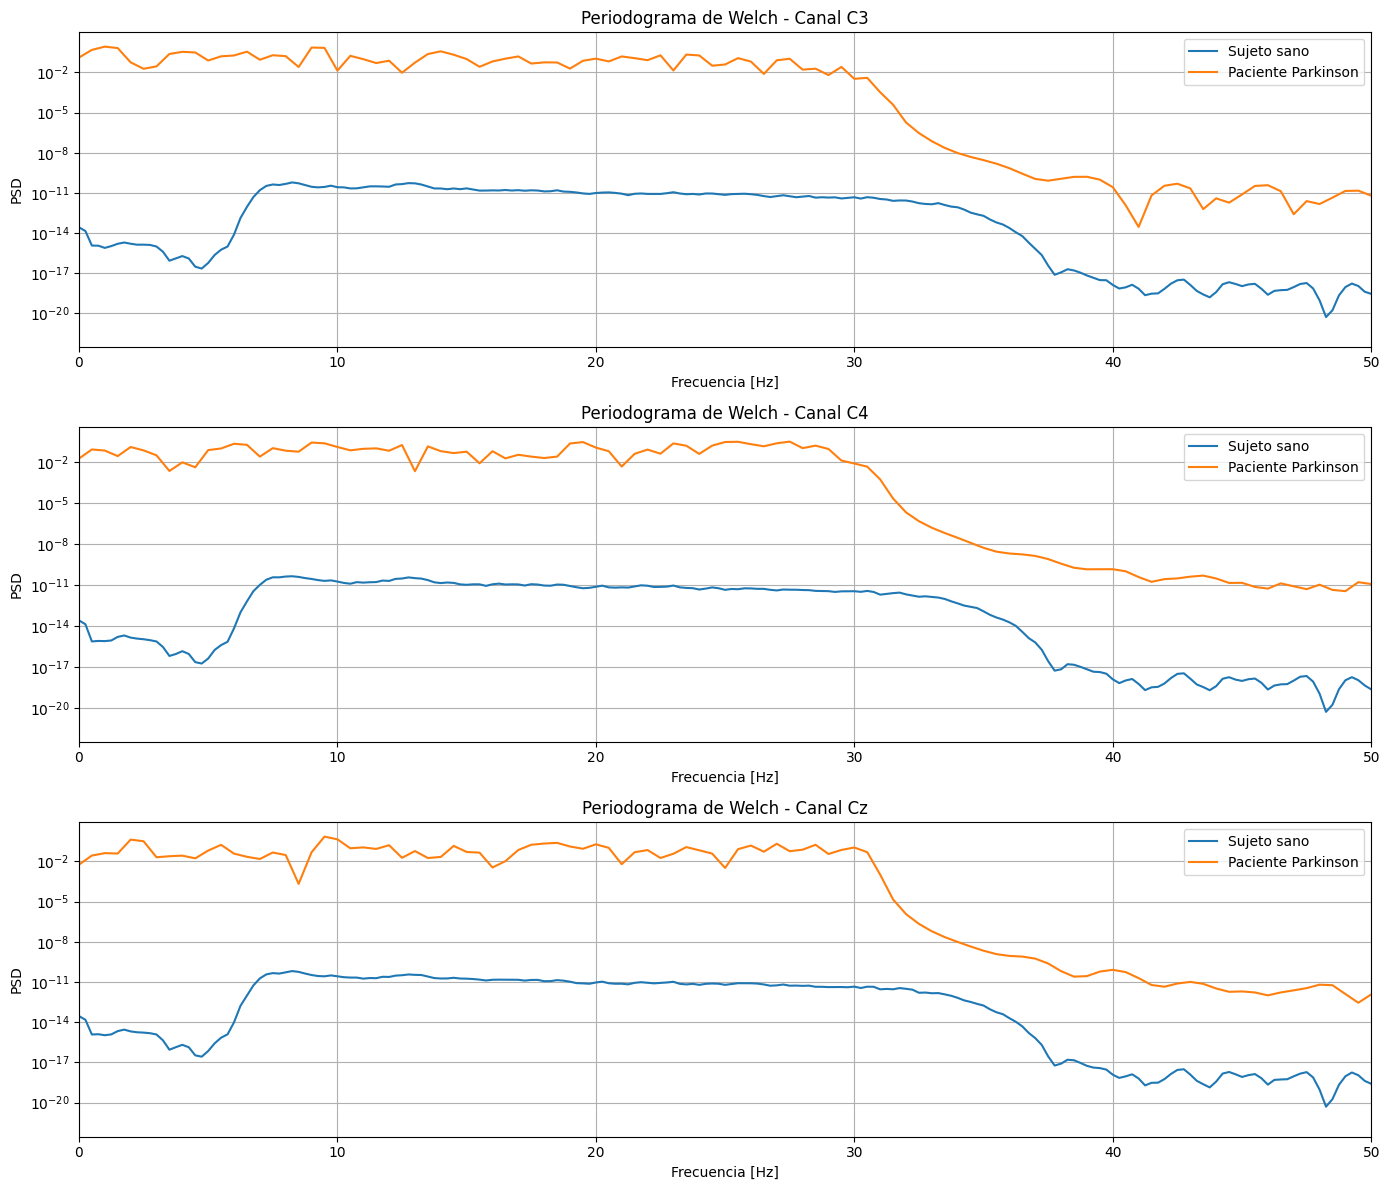

In [32]:
# CARGA DE ARCHIVOS
# Sujeto sano (.edf)
ruta_sano = 'Sujetos/S001/S001R04.edf'

# Paciente Parkinson (.mat)
ruta_parkinson = 'Parkinson_Info/Parkinson/P001_EP_reposo.mat'

# CARGA SUJETO SANO (.edf)
raw_sano = mne.io.read_raw_edf(
    ruta_sano,
    preload=True,
    verbose=False
)

# CARGA PACIENTE PARKINSON (.mat)
mat = loadmat(ruta_parkinson)

print(mat.keys())

# Extraer datos
senal_parkinson_total = mat['data']

print("Forma datos Parkinson:", senal_parkinson_total.shape)

# FRECUENCIAS DE MUESTREO
# Frecuencia sujeto sano
Fs_sano = raw_sano.info['sfreq']

# Frecuencia dataset Parkinson
Fs_parkinson = 1000

# PREPROCESAMIENTO SUJETO SANO
# Estandarizar nombres
mne.datasets.eegbci.standardize(raw_sano)

# Canales reales del EDF
canales_sano = ['C3', 'C4', 'Cz']

# Seleccionar canales
raw_sano.pick(canales_sano)

# FILTRADO
# Filtro notch 60 Hz
raw_sano.notch_filter(
    freqs=60.0,
    verbose=False
)

# Banda μ y β
raw_sano.filter(
    l_freq=8.0,
    h_freq=30.0,
    verbose=False
)

# MAPEO ENTRE DATASETS
# EDF sano -> dataset Parkinson
mapa_sano_parkinson = {
    'C3': 'C3',
    'C4': 'C4',
    'Cz': 'CZ'
}

# Índices reales dataset Parkinson
# Orden:
# ['C3','C1','CZ','C2','C4','O1','OZ','O2']

mapa_indices_parkinson = {
    'C3': 0,
    'CZ': 2,
    'C4': 4
}

# ENSAYO PARKINSON
trial = 0

# CREAR FIGURA
plt.figure(figsize=(14, 12))

# CICLO PARA C3, C4 y Cz
for i, canal_sano in enumerate(canales_sano):

    # NOMBRE EQUIVALENTE EN PARKINSON
    canal_parkinson = mapa_sano_parkinson[canal_sano]

    # SUJETO SANO
    idx_sano = raw_sano.ch_names.index(canal_sano)

    senal_sano = raw_sano.get_data()[idx_sano]

    senal_sano = np.squeeze(senal_sano)

    # PACIENTE PARKINSON
    idx_parkinson = mapa_indices_parkinson[canal_parkinson]

    # Estructura:
    # (ensayos, muestras, canales)

    senal_parkinson = senal_parkinson_total[
        trial,
        :,
        idx_parkinson
    ]

    senal_parkinson = np.squeeze(senal_parkinson)

    print(f"\nCanal {canal_sano}")
    print("Forma señal sano:", senal_sano.shape)
    print("Forma señal Parkinson:", senal_parkinson.shape)

    # PARÁMETROS DE WELCH
    # Ventana de 4 segundos
    nperseg_sano = int(4 * Fs_sano)

    nperseg_parkinson = int(4 * Fs_parkinson)

    # Ajuste automático
    nperseg_sano = min(
        nperseg_sano,
        len(senal_sano)
    )

    nperseg_parkinson = min(
        nperseg_parkinson,
        len(senal_parkinson)
    )

    # Solapamiento 50%
    noverlap_sano = nperseg_sano // 2

    noverlap_parkinson = nperseg_parkinson // 2

    # WELCH SUJETO SANO
    f_sano, Pxx_sano = ss.welch(
        senal_sano,
        fs=Fs_sano,
        window='hann',
        nperseg=nperseg_sano,
        noverlap=noverlap_sano
    )

    # WELCH PARKINSON
    f_parkinson, Pxx_parkinson = ss.welch(
        senal_parkinson,
        fs=Fs_parkinson,
        window='hann',
        nperseg=nperseg_parkinson,
        noverlap=noverlap_parkinson
    )

    # GRÁFICA
    plt.subplot(3, 1, i + 1)

    plt.semilogy(
        f_sano,
        Pxx_sano,
        label='Sujeto sano'
    )

    plt.semilogy(
        f_parkinson,
        Pxx_parkinson,
        label='Paciente Parkinson'
    )

    plt.xlim(0, 50)

    plt.xlabel('Frecuencia [Hz]')

    plt.ylabel('PSD')

    plt.title(
        f'Periodograma de Welch - Canal {canal_sano}'
    )

    plt.grid(True)

    plt.legend()

# AJUSTAR FIGURA
plt.tight_layout()

plt.show()

### **Análisis comparativo de los periodogramas de Welch**

Se realizó el análisis espectral mediante el periodograma de Welch para los canales C3, C4 y Cz de un sujeto sano y un paciente con enfermedad de Parkinson. Para la estimación de la densidad espectral de potencia (PSD) se utilizó una ventana de Hanning con un solapamiento del 50%.

La utilización de la ventana de Hanning permitió disminuir la fuga espectral causada por las discontinuidades en los extremos de cada segmento de señal, obteniendo una estimación espectral más suave y estable. El solapamiento del 50% se seleccionó debido a que incrementa la cantidad de segmentos utilizados en el promedio sin perder demasiada independencia estadística, reduciendo así la varianza del estimador espectral.

En los tres canales analizados se observan diferencias importantes entre el sujeto sano y el paciente con Parkinson. El paciente con Parkinson presenta una potencia espectral considerablemente mayor en bajas frecuencias, especialmente por debajo de 10 Hz, mientras que el sujeto sano exhibe niveles de potencia mucho menores en ese rango.

Este comportamiento puede asociarse a fenómenos de lentificación cortical característicos de enfermedades neurodegenerativas, donde aumenta la actividad en bandas lentas como delta y theta. Además, el sujeto sano muestra una disminución progresiva de la potencia a medida que aumenta la frecuencia, particularmente después de los 30 Hz.

En los canales C3 y C4, relacionados con la corteza motora, las diferencias son especialmente notorías, lo cual resulta coherente con las alteraciones motoras características de la enfermedad de Parkinson. El canal Cz también presenta un incremento marcado de potencia en el paciente con Parkinson, sugiriendo alteraciones generalizadas en la actividad cortical motora.

En términos generales, los periodogramas obtenidos evidencian una mayor actividad espectral de baja frecuencia en el paciente con Parkinson respecto al sujeto sano, indicando posibles alteraciones funcionales en la dinámica neuronal cortical asociadas a la enfermedad.

La resolución frecuencial está dada por:

$$\Delta f = \frac{F_s}{N}$$

donde:

- $F_s$ es la frecuencia de muestreo (256 Hz)
- $N$ es el número de muestras por segmento (256)

Esto justifica el uso de ventanas relativamente largas para mejorar la resolución espectral.